# Week 3 SARSA vs Q-learning analysis

This notebook loads the current `results/sarsa/MarsRover` and `results/qlearning/MarsRover` runs, aggregates rewards across available seeds with rliable's IQM metric, and plots training and evaluation curves with confidence intervals.

In [7]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from rliable import metrics
from rliable.library import get_interval_estimates
from rliable.plot_utils import plot_sample_efficiency_curve

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results").exists():
    REPO_ROOT = Path.cwd().parents[1]

RESULTS_ROOT = REPO_ROOT / "results"
ENV_NAME = "MarsRover"
ALGORITHMS = ["sarsa", "qlearning"]
PLOT_DIR = REPO_ROOT / "rl_exercises" / "week_3" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "figure.dpi": 140,
        "savefig.dpi": 300,
    }
)

In [8]:
def discover_seed_dirs(algorithm: str, env_name: str = ENV_NAME) -> list[Path]:
    run_root = RESULTS_ROOT / algorithm / env_name
    return sorted(path for path in run_root.glob("seed_*") if path.is_dir())


def load_scores(
    algorithm: str,
    csv_name: str,
    step_col: str,
    reward_col: str,
    env_name: str = ENV_NAME,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    seed_frames = []

    for seed_dir in discover_seed_dirs(algorithm, env_name):
        csv_path = seed_dir / csv_name
        if not csv_path.exists():
            continue

        frame = pd.read_csv(csv_path)
        frame["seed"] = int(seed_dir.name.removeprefix("seed_"))
        seed_frames.append(frame[["seed", step_col, reward_col]])

    if not seed_frames:
        raise FileNotFoundError(
            f"No {csv_name} files found for {algorithm} in {RESULTS_ROOT / algorithm / env_name}"
        )

    common_steps = sorted(set(seed_frames[0][step_col]))
    for frame in seed_frames[1:]:
        common_steps = sorted(set(common_steps).intersection(frame[step_col]))

    if not common_steps:
        raise ValueError(f"No shared {step_col} values across {algorithm} seeds")

    aligned_scores = []
    aligned_frames = []
    for frame in seed_frames:
        aligned = frame.set_index(step_col).loc[common_steps].reset_index()
        aligned_frames.append(aligned)
        aligned_scores.append(aligned[reward_col].to_numpy(dtype=float))

    return (
        np.asarray(common_steps),
        np.vstack(aligned_scores),
        pd.concat(aligned_frames, ignore_index=True),
    )


def build_score_dict(csv_name: str, step_col: str, reward_col: str):
    steps_by_algorithm = {}
    scores_by_algorithm = {}
    frames_by_algorithm = {}

    for algorithm in ALGORITHMS:
        steps, scores, frame = load_scores(algorithm, csv_name, step_col, reward_col)
        steps_by_algorithm[algorithm] = steps
        scores_by_algorithm[algorithm] = scores
        frames_by_algorithm[algorithm] = frame.assign(algorithm=algorithm)

    common_steps = sorted(
        set.intersection(*(set(steps) for steps in steps_by_algorithm.values()))
    )
    common_steps = np.asarray(common_steps)

    aligned_scores = {}
    for algorithm, scores in scores_by_algorithm.items():
        step_to_index = {
            step: idx for idx, step in enumerate(steps_by_algorithm[algorithm])
        }
        indices = [step_to_index[step] for step in common_steps]
        aligned_scores[algorithm] = scores[:, indices]

    all_frames = pd.concat(frames_by_algorithm.values(), ignore_index=True)
    return common_steps, aligned_scores, all_frames


def iqm_over_time(scores: np.ndarray) -> np.ndarray:
    return np.array(
        [
            metrics.aggregate_iqm(scores[:, eval_idx])
            for eval_idx in range(scores.shape[-1])
        ]
    )


def rliable_curve(scores_by_algorithm: dict[str, np.ndarray], reps: int = 2000):
    min_seeds = min(scores.shape[0] for scores in scores_by_algorithm.values())
    reps = reps if min_seeds > 1 else 1
    return get_interval_estimates(scores_by_algorithm, iqm_over_time, reps=reps)


def tidy_rliable_plot(linewidth: float = 1.1, band_alpha: float = 0.12):
    ax = plt.gca()
    for line in ax.lines:
        line.set_linewidth(linewidth)
        line.set_alpha(0.95)
    for band in ax.collections:
        band.set_alpha(band_alpha)
    return ax

In [9]:
train_steps, train_scores, train_df = build_score_dict(
    csv_name="train_rewards.csv",
    step_col="steps",
    reward_col="train_rewards",
)
eval_steps, eval_scores, eval_df = build_score_dict(
    csv_name="eval_rewards.csv",
    step_col="eval_steps",
    reward_col="eval_rewards",
)

run_counts = pd.DataFrame(
    {
        "algorithm": ALGORITHMS,
        "train_seeds": [train_scores[algorithm].shape[0] for algorithm in ALGORITHMS],
        "train_points": [train_scores[algorithm].shape[1] for algorithm in ALGORITHMS],
        "eval_seeds": [eval_scores[algorithm].shape[0] for algorithm in ALGORITHMS],
        "eval_points": [eval_scores[algorithm].shape[1] for algorithm in ALGORITHMS],
    }
)
run_counts

,algorithm,train_seeds,train_points,eval_seeds,eval_points
0,sarsa,1,15000,1,1500
1,qlearning,1,15000,1,1500


ValueError: x and y must have same first dimension, but have shapes (1,) and (15000,)

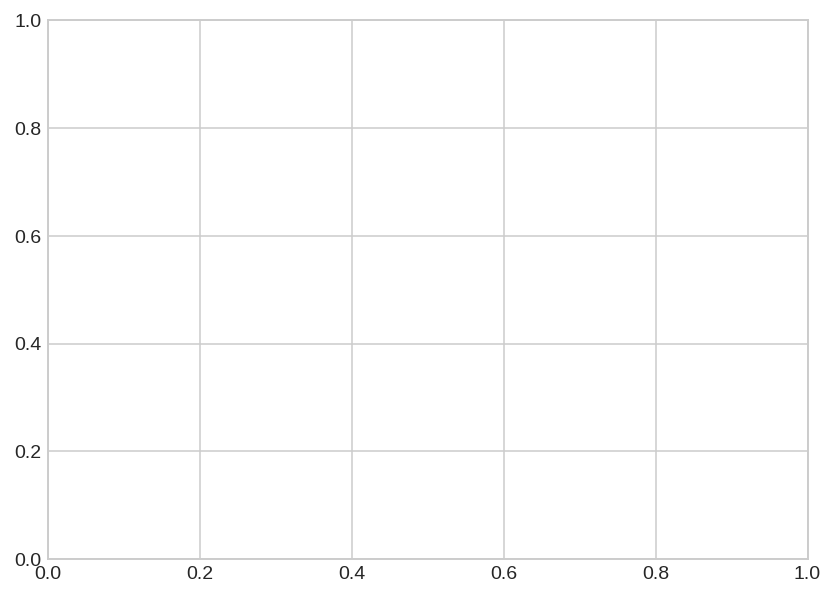

In [ ]:
train_iqm_scores, train_iqm_cis = rliable_curve(train_scores)

plot_sample_efficiency_curve(
    train_steps + 1,
    train_iqm_scores,
    train_iqm_cis,
    algorithms=ALGORITHMS,
    xlabel="Training step",
    ylabel="IQM train reward",
)
tidy_rliable_plot(linewidth=1.0)
plt.title("SARSA vs Q-learning: training rewards")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "sarsa_qlearning_train_iqm.png")
plt.show()

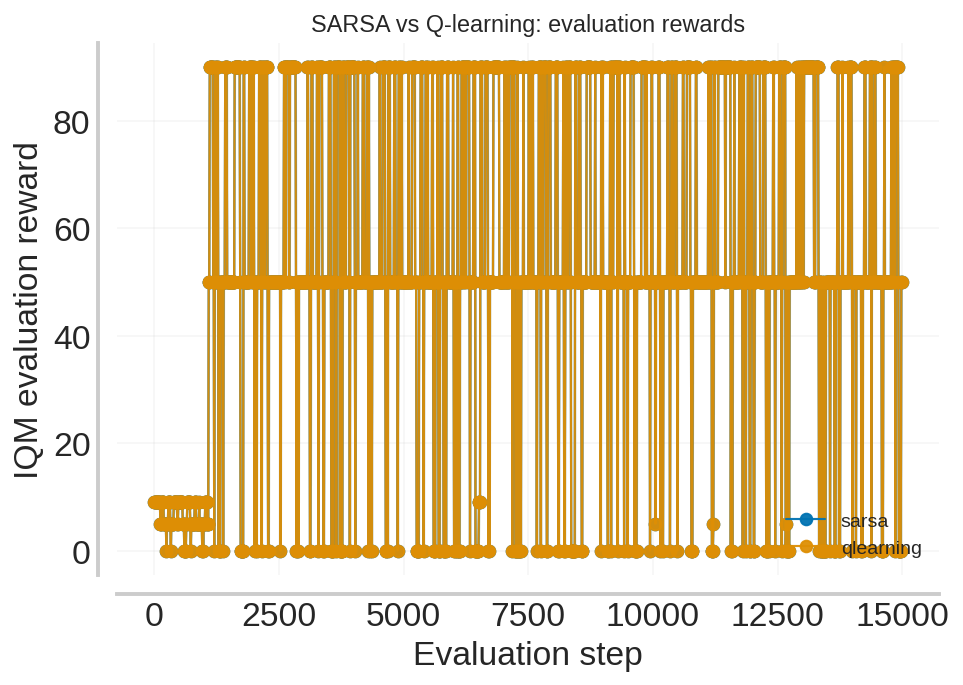

In [11]:
eval_iqm_scores, eval_iqm_cis = rliable_curve(eval_scores)

plot_sample_efficiency_curve(
    eval_steps + 1,
    eval_iqm_scores,
    eval_iqm_cis,
    algorithms=ALGORITHMS,
    xlabel="Evaluation step",
    ylabel="IQM evaluation reward",
)
tidy_rliable_plot()
plt.title("SARSA vs Q-learning: evaluation rewards")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "sarsa_qlearning_eval_iqm.png")
plt.show()

In [12]:
def summarize_final_performance(
    scores_by_algorithm: dict[str, np.ndarray], window: int = 100
):
    rows = []
    for algorithm, scores in scores_by_algorithm.items():
        tail = scores[:, -min(window, scores.shape[1]) :]
        rows.append(
            {
                "algorithm": algorithm,
                "n_seeds": scores.shape[0],
                "final_iqm": metrics.aggregate_iqm(scores[:, -1]),
                "best_iqm": max(
                    metrics.aggregate_iqm(scores[:, idx])
                    for idx in range(scores.shape[1])
                ),
                f"last_{window}_mean": tail.mean(),
                f"last_{window}_iqm": metrics.aggregate_iqm(tail.reshape(-1)),
            }
        )
    return pd.DataFrame(rows).sort_values("final_iqm", ascending=False)


train_summary = summarize_final_performance(train_scores)
eval_summary = summarize_final_performance(eval_scores)

display(train_summary.style.format(precision=2).set_caption("Training reward summary"))
display(eval_summary.style.format(precision=2).set_caption("Evaluation reward summary"))

,algorithm,n_seeds,final_iqm,best_iqm,last_100_mean,last_100_iqm
0,sarsa,1,10.00,10.00,4.30,3.60
1,qlearning,1,10.00,10.00,4.30,3.60


,algorithm,n_seeds,final_iqm,best_iqm,last_100_mean,last_100_iqm
0,sarsa,1,50.00,90.00,51.80,50.00
1,qlearning,1,50.00,90.00,51.80,50.00


Note: confidence intervals are only meaningful when there are multiple independent seeds. With only `seed_0`, the IQM curve is just that single run's reward curve and the interval collapses to the same value.